In [1]:
%matplotlib inline

from glob import glob
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import os

os.environ['PATH'] = '/Library/TeX/texbin:' + os.environ['PATH']

In [2]:
LABELS = {
#    'ky.matc'       : 'Entropy-Optimal Sampler',
#    'ky.enc'        : 'Entropy-Optimal Sampler',
 #   'rej.binary'    : 'Rejection Sampler (Dyadic; Binary Search)',
  #  'rej.table'     : 'Rejection Sampler (Dyadic; Lookup Table)',
   # 'rej.matc'      : 'Rejection Sampler (Dyadic; New Method)',
    'rej.enc'       : 'Fast Loaded Dice Roller (FLDR)',
    #'rej.uniform'   : 'Rejection Sampler (Uniform)',
    #'interval'      : 'Exact Interval Sampler',
    #'boost.alias'   : 'Alias Sampler',
    #'std.inversion' : 'Inversion Sampler',
    'alias.exact'   : 'Exact Alias Sampler',
    'alias.integers' : 'Alias Integers',
    'aldr'          : 'ALDR',
    'alias.rust'    : 'Alias Rust',
}

In [3]:
def get_entropy(fname):
    with open(fname, 'r') as f:
        return float(f.readlines()[-1])

In [4]:
# Penser à changer le n et le Z en fonction du dossier que l'on veut charger
n = 32768
Z = 524288
seed = 2
pattern = '/dists.%d.%d.%d' % (n, Z, seed)
f_runtimes = sorted(glob('../%s/*.runtimes' % (pattern,)))
f_sizes = sorted(glob('../%s/*.sizes' % (pattern,)))
f_dists = sorted(glob('../%s/*.dist' % (pattern,)))
f_bits = sorted(glob('../%s/*.bits' % (pattern,)))
runtimes = np.asarray([np.loadtxt(f) for f in f_runtimes])
sizes = np.asarray([np.loadtxt(f) for f in f_sizes])
entropies = np.asarray([get_entropy(f) for f in f_dists])
bits = np.asarray([np.loadtxt(f) for f in f_bits])
num_samples = 1e6
rates = runtimes / num_samples
samplers = [x.split('/')[-1].replace('.runtimes', '') for x in f_runtimes]

In [5]:
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'sans-serif'

#### Plot Memory--Rate

In [6]:
selection = [
    'rej.enc',
    #'ky.enc',
    #'rej.binary',
    #'rej.uniform',
    #'rej.table',
    #'interval',
    'alias.exact',
    'alias.integers',
    'aldr',
    'alias.rust',
]

In [7]:
samplers

['aldr', 'alias.exact', 'alias.integers', 'alias.rust', 'rej.enc']

In [8]:
def run_plot_rate_size(samplers, rates, sizes):
    fig, ax = plt.subplots()
    collections = []
    
    for sampler, rate, size in zip(samplers, rates, sizes):
        if sampler not in selection:
            continue
        print(sampler)
        sc = ax.scatter(rate, size, label=LABELS[sampler], s=10, marker='.', alpha=1)
        collections.append((sampler, sc))

    ax.set_xscale('log', base=2)
    ax.set_yscale('log', base=2)

    ax.set_xlabel('Sampler Runtime (Seconds per Sample)', fontsize=14)
    ax.set_ylabel('Sampler Memory (Bytes)', fontsize=14)

    ax.xaxis.set_major_locator(
        ticker.LogLocator(base=2., subs=(1,), numticks=100))
    ax.xaxis.set_minor_formatter(ticker.NullFormatter())
    ax.xaxis.set_minor_locator(
        ticker.LogLocator(base=2., subs=np.arange(11, 20)*.1, numticks=24))

    ax.yaxis.set_major_locator(
        ticker.LogLocator(base=2., subs=(1,), numticks=20))
    ax.yaxis.set_minor_formatter(ticker.NullFormatter())
    ax.yaxis.set_minor_locator(
        ticker.LogLocator(base=2., subs=np.arange(11,20)*.1, numticks=100))

    fig.set_size_inches((8, 6))
    fig.set_facecolor('white')
    fig.set_tight_layout(True)
    
    return fig, ax, collections

aldr
alias.exact
alias.integers
alias.rust
rej.enc


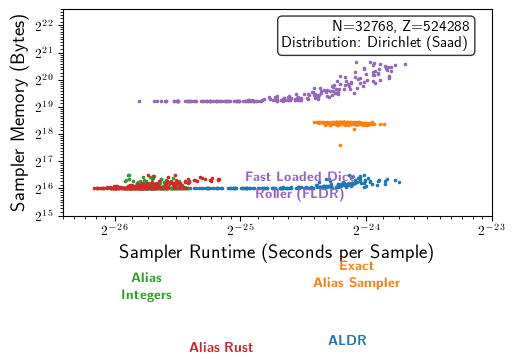

In [9]:
fig, ax, collections = run_plot_rate_size(samplers, rates, sizes)

# Create a mapping of sampler names to colors
sampler_colors = {sampler: sc.get_facecolors()[0] for sampler, sc in collections}

ax.set_xlim([1.5*2**-27, 2**-23])
ax.set_ylim([2**15, 1.5*2**22])

# Add legend for N, Z, and distribution type at top right
legend_text = f'N={n}, Z={Z}\nDistribution: Dirichlet (Saad)'
ax.text(0.95, 0.95, legend_text, transform=ax.transAxes, ha='right', va='top', fontsize=11, bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

# Add labels with matching colors
ax.text(
    0.95*2**-24, 0.5*2**14,
    r'\begin{center}\textbf{Exact}\\\textbf{Alias Sampler}\end{center}',
    horizontalalignment='center',
    color=sampler_colors['alias.exact'])
ax.text(
    0.7*2**-24, 1.2*2**16,
    r'\begin{center}\textbf{Fast Loaded Dice}\\\textbf{Roller (FLDR)}\end{center}',
    horizontalalignment='center',
    color=sampler_colors['rej.enc'])
ax.text(
    0.9*2**-24, 1.2*2**10,
    r'\begin{center}\textbf{ALDR}\end{center}',
    horizontalalignment='center',
    color=sampler_colors['aldr'])
ax.text(
    0.9*2**-25, 2**10,
    r'\begin{center}\textbf{Alias Rust}\end{center}',
    horizontalalignment='center',
    color=sampler_colors['alias.rust'])
ax.text(
    1.2*2**-26, 1.5*2**12,
    r'\begin{center}\textbf{Alias}\\\textbf{Integers}\end{center}',
    horizontalalignment='center',
    color=sampler_colors['alias.integers'])
fig.set_tight_layout(True)
fig.set_size_inches(5.25, 3.5)
for ext in ['pdf', 'png']:
    fig.savefig('figure-4-interpolation-memory.%s' % (ext,))

#### Plot Entropy--Rate

In [10]:
from scipy.signal import savgol_filter

In [11]:
def run_plot_entropy_rate(samplers, entropies, rates):
    fig, ax = plt.subplots()

    for sampler, rate in zip(samplers, rates):
        if sampler not in selection:
            continue

        sc = ax.scatter([], [], label=rf'\textbf{{{LABELS[sampler]}}}', s=50)
        color = sc.get_facecolors()[0]

        ax.scatter(entropies, rate, color=color, marker='.', s=2)

        # Régression SANS sklearn
        x = entropies
        y = np.log2(rate)

        a, b = np.polyfit(x, y, 1)

        x_line = np.linspace(x.min(), x.max(), 200)
        y_line = 2 ** (a * x_line + b)

        ax.plot(x_line, y_line, linestyle='--', color=color)

        print(f"{sampler} slope (entropy): {a:.3f}")

    ax.set_yscale('log', base=2)

    ax.set_xlabel('Entropy of Target Distribution', fontsize=14)
    ax.set_ylabel('Sampler Runtime (Seconds per Sample)', fontsize=12)

    ax.legend(loc='upper left', bbox_to_anchor=(1,1))

    fig.set_tight_layout(True)
    fig.set_size_inches((8, 6))

    return fig, ax

aldr slope (entropy): 0.135
alias.exact slope (entropy): 0.011
alias.integers slope (entropy): -0.001
alias.rust slope (entropy): 0.032
rej.enc slope (entropy): 0.122


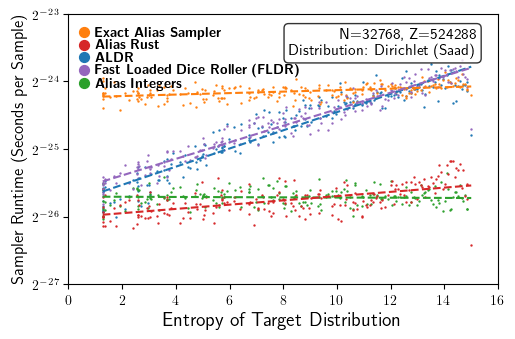

In [12]:
fig, ax = run_plot_entropy_rate(samplers, entropies, rates)

ax.set_xlim([0, 16])
ax.set_ylim([2**-27, 2**-23])

# Add legend for N, Z, and distribution type at top right
legend_text = f'N={n}, Z={Z}\nDistribution: Dirichlet (Saad)'
ax.text(0.95, 0.95, legend_text, transform=ax.transAxes, ha='right', va='top', fontsize=11, bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

handles, labels = ax.get_legend_handles_labels()
order = [6, 1, 3, 5, 0, 4, 2]
order = [i for i in order if i < len(handles)]
ax.legend(
    [handles[idx] for idx in order],
    [labels[idx] for idx in order],
    loc='upper left',
    framealpha=0,
    labelspacing=0,
    handletextpad=.5,
    handlelength=.5,
#     bbox_to_anchor=(1,1),
)

fig.set_tight_layout(True)
fig.set_size_inches(5.25, 3.5)
for ext in ['pdf', 'png']:
    fig.savefig('figure-4-interpolation-entropy.%s' % (ext,))

#### Plot Entropy--Bits

In [13]:
def run_plot_entropy_bits(samplers, entropies, bits):
    fig, ax = plt.subplots()

    for sampler, bit in zip(samplers, bits):
        if sampler not in selection:
            continue

        sc = ax.scatter([], [], label=rf'\textbf{{{LABELS[sampler]}}}', s=50)
        color = sc.get_facecolors()[0]

        ax.scatter(entropies, bit, color=color, marker='.', s=2)

        # Régression SANS sklearn
        x = entropies
        #y = np.log2(bit)
        y = bit

        a, b = np.polyfit(x, y, 1)

        x_line = np.linspace(x.min(), x.max(), 200)
        #y_line = 2 ** (a * x_line + b)
        y_line = (a * x_line + b)

        ax.plot(x_line, y_line, linestyle='--', color=color)

        print(f"{sampler} slope (entropy): {a:.3f}")

    ax.set_yscale('linear')

    ax.set_xlabel('Entropy of Target Distribution', fontsize=14)
    ax.set_ylabel('Average number of bits consumed', fontsize=12)

    ax.legend(loc='upper left', bbox_to_anchor=(1,1))

    fig.set_tight_layout(True)
    fig.set_size_inches((8, 6))

    return fig, ax

aldr slope (entropy): 1.040
alias.exact slope (entropy): -0.000
alias.integers slope (entropy): -0.012
alias.rust slope (entropy): -0.008
rej.enc slope (entropy): 1.040


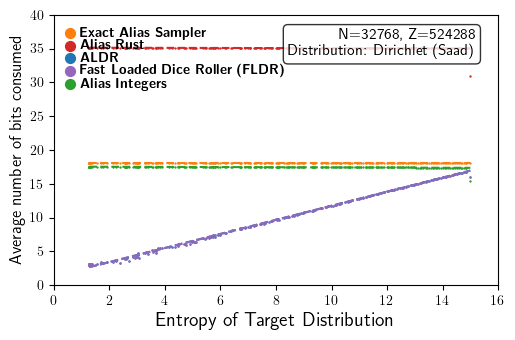

In [14]:
fig, ax = run_plot_entropy_bits(samplers, entropies, bits)

ax.set_xlim([0, 16])
ax.set_ylim([0, 40])

# Add legend for N, Z, and distribution type at top right
legend_text = f'N={n}, Z={Z}\nDistribution: Dirichlet (Saad)'
ax.text(0.95, 0.95, legend_text, transform=ax.transAxes, ha='right', va='top', fontsize=11, bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

handles, labels = ax.get_legend_handles_labels()
order = [6, 1, 3, 5, 0, 4, 2]
order = [i for i in order if i < len(handles)]
ax.legend(
    [handles[idx] for idx in order],
    [labels[idx] for idx in order],
    loc='upper left',
    framealpha=0,
    labelspacing=0,
    handletextpad=.5,
    handlelength=.5,
#     bbox_to_anchor=(1,1),
)

fig.set_tight_layout(True)
fig.set_size_inches(5.25, 3.5)
for ext in ['pdf', 'png']:
    fig.savefig('figure-4-interpolation-bits.%s' % (ext,))